# Proyecto de aula — Fundamentos de Ciencia de Datos

## Análisis exploratorio y caracterización de variables fisicoquímicas asociadas a la calidad del vino

---

**Autores**

| Nombre | Correo institucional |
|---|---|
| José Camilo Loaiza Hoyos | `camilo.loaiza1@udea.edu.co` |
| Sarai Restrepo Rodríguez | `sarai.restrepo@udea.edu.co` |

**Curso:** Fundamentos de Ciencia de Datos
**Docente:** María Bernarda Salazar Sánchez.
**Programa:** Ingeniería de Sistemas - Universidad de Antioquia
**Semestre:** 2026-1

**Conjunto de datos:** *Wine Quality* — UCI Machine Learning Repository (Cortez et al., 2009).
**Repositorio:** <https://github.com/caamilo03/wine-quality>

---

## Tabla de contenido

1. **Unidad 1 — Comprensión y contextualización del problema** *(esta entrega)*
   1. Introducción y pregunta de investigación
   2. Objetivos
   3. Descripción del conjunto de datos
   4. Configuración del entorno
   5. Carga de datos
   6. Inspección inicial
   7. Hallazgos preliminares y próximos pasos
2. *Unidad 2 — Análisis exploratorio de datos* (próxima entrega)
3. *Unidad 3 — Detección y tratamiento de datos atípicos*
4. *Unidad 4 — Imputación, escalamiento y transformación*
5. *Síntesis y dataset procesado*

## 1. Introducción y pregunta de investigación

La evaluación de la calidad del vino es, tradicionalmente, una tarea sensorial realizada por catadores expertos: un proceso costoso, subjetivo y poco escalable. La industria vitivinícola moderna, sin embargo, dispone de mediciones fisicoquímicas que pueden obtenerse de manera rutinaria en laboratorio (acidez, contenido de azúcar, dióxido de azufre, alcohol, entre otras). Surge entonces una pregunta natural: **¿qué tan bien describen estas variables objetivas la calidad percibida del vino?**

El presente trabajo aborda este problema a partir del conjunto de datos *Wine Quality* del UCI Machine Learning Repository (Cortez et al., 2009), que reúne mediciones de vinos *Vinho Verde* portugueses (variantes tinto y blanco) junto con una calificación sensorial entera entre 0 y 10 asignada por un panel de catadores.

> **Pregunta de investigación.** *¿Qué variables fisicoquímicas permiten predecir de mejor manera la calidad del vino?*

Este proyecto no construye un modelo predictivo: su alcance es **exploratorio y descriptivo**. Buscamos identificar qué variables muestran asociación más clara con la calidad, qué patrones diferencian el vino tinto del blanco, y qué tratamientos de calidad de datos (atípicos, escalamiento, transformación) resultan necesarios antes de cualquier modelado posterior.

### 1.1 Objetivos

**Objetivo general.** Caracterizar las variables fisicoquímicas del conjunto *Wine Quality* y determinar cuáles presentan mayor asociación con la calidad sensorial del vino, mediante un proceso analítico completo de ciencia de datos.

**Objetivos específicos.**
1. Describir la estructura, tipos y calidad inicial del conjunto de datos (Unidad 1).
2. Aplicar técnicas de análisis exploratorio univariado, bivariado y multivariado para identificar patrones y relaciones (Unidad 2).
3. Detectar y documentar valores atípicos mediante métodos gráficos, estadísticos y de aprendizaje automático (Unidad 3).
4. Aplicar estrategias de imputación, escalamiento y transformación que preparen los datos para análisis posteriores (Unidad 4).
5. Sintetizar los hallazgos en un artículo académico que articule la pregunta de investigación con la evidencia empírica obtenida.

### 1.2 Descripción del conjunto de datos

El repositorio UCI provee dos archivos separados —uno por cada tipo de vino— con la misma estructura de variables. Las dimensiones reportadas por la fuente original son:

| Subconjunto | Observaciones | Variables |
|---|---:|---:|
| Vino tinto (`winequality-red.csv`) | 1 599 | 12 |
| Vino blanco (`winequality-white.csv`) | 4 898 | 12 |

Las once primeras variables son mediciones fisicoquímicas continuas; la duodécima, `quality`, es una variable ordinal entera obtenida como **mediana de tres evaluaciones sensoriales independientes** realizadas por catadores. La siguiente tabla resume cada atributo:

| # | Variable | Unidad | Tipo | Descripción breve |
|---:|---|---|---|---|
| 1 | `fixed acidity` | g(ácido tartárico)/dm³ | continua | Ácidos no volátiles, principal componente de la acidez del vino. |
| 2 | `volatile acidity` | g(ácido acético)/dm³ | continua | Ácidos volátiles; valores altos producen sabor a vinagre. |
| 3 | `citric acid` | g/dm³ | continua | Aporta frescura y aroma cítrico en pequeñas cantidades. |
| 4 | `residual sugar` | g/dm³ | continua | Azúcar remanente tras la fermentación. |
| 5 | `chlorides` | g(NaCl)/dm³ | continua | Contenido de sal. |
| 6 | `free sulfur dioxide` | mg/dm³ | continua | SO₂ libre; previene crecimiento microbiano y oxidación. |
| 7 | `total sulfur dioxide` | mg/dm³ | continua | SO₂ libre + ligado. |
| 8 | `density` | g/cm³ | continua | Densidad del líquido, depende de alcohol y azúcar. |
| 9 | `pH` | — | continua | Acidez en escala logarítmica (0–14). |
| 10 | `sulphates` | g(K₂SO₄)/dm³ | continua | Aditivo antimicrobiano y antioxidante. |
| 11 | `alcohol` | % vol. | continua | Porcentaje de alcohol. |
| 12 | `quality` | — | ordinal (0–10) | Calificación sensorial mediana del panel de catadores. |

**Justificación metodológica.** El conjunto es ideal para un proyecto de fundamentos: variables completamente numéricas, escala manejable, dominio interpretable y una variable objetivo (`quality`) que permite estudiar relaciones bivariadas y multivariadas con sentido aplicado. La existencia de dos subconjuntos (tinto y blanco) habilita además un análisis comparativo enriquecido.

### 1.3 Configuración del entorno

Se utilizan las librerías estándar del ecosistema científico de Python: `pandas` para manipulación tabular, `numpy` para operaciones numéricas, `matplotlib` y `seaborn` para visualización. Se fija una semilla aleatoria global para asegurar reproducibilidad en pasos posteriores que involucren muestreo o métodos estocásticos.

In [78]:
# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades
from pathlib import Path

# --- Reproducibilidad ----------------------------------------------------
SEED = 42
np.random.seed(SEED)

# --- Configuración estética de las gráficas ------------------------------
sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# --- Configuración de pandas --------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# --- Rutas del proyecto --------------------------------------------------
RAIZ = Path.cwd().parent if Path.cwd().name == "proyecto_aula" else Path.cwd()
RUTA_DATOS = RAIZ / "datos"
RUTA_PROCESADOS = RUTA_DATOS / "procesados"
RUTA_FIGURAS = RAIZ / "articulo" / "figuras"

print(f"Raíz del proyecto:  {RAIZ}")
print(f"Datos crudos:       {RUTA_DATOS}")
print(f"Datos procesados:   {RUTA_PROCESADOS}")
print(f"Figuras (artículo): {RUTA_FIGURAS}")

Raíz del proyecto:  c:\Users\Camilo\Documents\F. Ciencia de datos\wine-quality
Datos crudos:       c:\Users\Camilo\Documents\F. Ciencia de datos\wine-quality\datos
Datos procesados:   c:\Users\Camilo\Documents\F. Ciencia de datos\wine-quality\datos\procesados
Figuras (artículo): c:\Users\Camilo\Documents\F. Ciencia de datos\wine-quality\articulo\figuras


### 1.4 Carga de datos

Los archivos del UCI utilizan punto y coma (`;`) como separador. Cargamos cada subconjunto por separado, añadimos una variable categórica `tipo` que identifica el origen (tinto o blanco) y los unimos en un único `DataFrame` para facilitar el análisis comparativo.

In [79]:
tinto = pd.read_csv(RUTA_DATOS / "winequality-red.csv", sep=";")
blanco = pd.read_csv(RUTA_DATOS / "winequality-white.csv", sep=";")

# Etiqueta de origen para análisis comparativo
tinto["tipo"] = "tinto"
blanco["tipo"] = "blanco"

# Conjunto unificado
vinos = pd.concat([tinto, blanco], ignore_index=True)
vinos["tipo"] = vinos["tipo"].astype("category")

print(f"Tinto:    {tinto.shape[0]:>5} filas × {tinto.shape[1]} columnas")
print(f"Blanco:   {blanco.shape[0]:>5} filas × {blanco.shape[1]} columnas")
print(f"Unificado:{vinos.shape[0]:>5} filas × {vinos.shape[1]} columnas")

Tinto:     1599 filas × 13 columnas
Blanco:    4898 filas × 13 columnas
Unificado: 6497 filas × 13 columnas


In [80]:
vinos.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,tinto
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5,tinto
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5,tinto
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6,tinto
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,tinto


### 1.5 Inspección inicial

Antes de cualquier análisis exploratorio formal (Unidad 2), verificamos cuatro aspectos básicos de calidad de datos:

1. **Tipos y memoria.** ¿Las variables fueron leídas con el tipo correcto?
2. **Resumen estadístico.** Rangos, medianas y dispersión por variable.
3. **Valores faltantes y duplicados.** ¿Hay registros incompletos o repetidos?
4. **Distribución por tipo y por calidad.** ¿Cuán balanceado está el conjunto?

#### 1.5.1 Tipos de datos y uso de memoria

In [81]:
vinos.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         6497 non-null   float64 
 1   volatile acidity      6497 non-null   float64 
 2   citric acid           6497 non-null   float64 
 3   residual sugar        6497 non-null   float64 
 4   chlorides             6497 non-null   float64 
 5   free sulfur dioxide   6497 non-null   float64 
 6   total sulfur dioxide  6497 non-null   float64 
 7   density               6497 non-null   float64 
 8   pH                    6497 non-null   float64 
 9   sulphates             6497 non-null   float64 
 10  alcohol               6497 non-null   float64 
 11  quality               6497 non-null   int64   
 12  tipo                  6497 non-null   category
dtypes: category(1), float64(11), int64(1)
memory usage: 615.8 KB


#### 1.5.2 Resumen estadístico

In [82]:
vinos.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,"6,497.0000",7.2153,1.2964,3.8000,6.4000,7.0000,7.7000,15.9000
volatile acidity,"6,497.0000",0.3397,0.1646,0.0800,0.2300,0.2900,0.4000,1.5800
citric acid,"6,497.0000",0.3186,0.1453,0.0000,0.2500,0.3100,0.3900,1.6600
residual sugar,"6,497.0000",5.4432,4.7578,0.6000,1.8000,3.0000,8.1000,65.8000
chlorides,"6,497.0000",0.0560,0.0350,0.0090,0.0380,0.0470,0.0650,0.6110
free sulfur dioxide,"6,497.0000",30.5253,17.7494,1.0000,17.0000,29.0000,41.0000,289.0000
total sulfur dioxide,"6,497.0000",115.7446,56.5219,6.0000,77.0000,118.0000,156.0000,440.0000
density,"6,497.0000",0.9947,0.0030,0.9871,0.9923,0.9949,0.9970,1.0390
pH,"6,497.0000",3.2185,0.1608,2.7200,3.1100,3.2100,3.3200,4.0100
sulphates,"6,497.0000",0.5313,0.1488,0.2200,0.4300,0.5100,0.6000,2.0000


#### 1.5.3 Valores faltantes y duplicados

In [83]:
faltantes = vinos.isna().sum()
faltantes = faltantes[faltantes > 0]

print("Valores faltantes por columna:")
if faltantes.empty:
    print("  ninguno.")
else:
    print(faltantes.to_string())

n_dup = vinos.duplicated().sum()
print(f"\nFilas duplicadas exactas: {n_dup} "
      f"({100 * n_dup / len(vinos):.2f} % del total)")

Valores faltantes por columna:
  ninguno.

Filas duplicadas exactas: 1177 (18.12 % del total)


#### 1.5.4 Distribución por tipo y por calidad

In [84]:
conteo_tipo = vinos["tipo"].value_counts().rename("n")
conteo_tipo_pct = (conteo_tipo / conteo_tipo.sum() * 100).round(2).rename("%")
pd.concat([conteo_tipo, conteo_tipo_pct], axis=1)

,n,%
tipo,,
blanco,4898,75.3900
tinto,1599,24.6100


In [85]:
tabla_quality = (
    vinos.groupby(["tipo", "quality"], observed=True)
         .size()
         .unstack(fill_value=0)
         .sort_index(axis=1)
)
tabla_quality["total"] = tabla_quality.sum(axis=1)
tabla_quality

quality,3,4,5,6,7,8,9,total
tipo,,,,,,,,
blanco,20,163,1457,2198,880,175,5,4898
tinto,10,53,681,638,199,18,0,1599


### 1.6 Hallazgos preliminares y próximos pasos

A partir de la inspección inicial podemos consignar las siguientes observaciones, que servirán como punto de partida para la Unidad 2:

- **Estructura.** El conjunto unificado contiene **6 497 observaciones** y **13 columnas** (11 variables fisicoquímicas continuas, la variable objetivo `quality` y la variable categórica `tipo`).
- **Calidad inicial de los datos.** No se reportan valores faltantes en la fuente original; sin embargo, hay un número no despreciable de **filas duplicadas exactas**, cuyo tratamiento se discutirá en la Unidad 4.
- **Desbalance entre subconjuntos.** El vino blanco representa aproximadamente tres cuartas partes del total, lo cual debe considerarse al hacer comparaciones por tipo.
- **Variable objetivo concentrada en clases medias.** La mayoría de los vinos reciben puntuaciones entre 5 y 7; las clases extremas (3, 4, 8, 9) son muy escasas. Este es un caso típico de **desbalance de clases ordinales** que será relevante en cualquier modelado supervisado posterior.
- **Escalas heterogéneas.** Las variables se mueven en órdenes de magnitud muy distintos (densidad $\approx 1$ vs. dióxido de azufre total con valores $> 200$). Esto anticipa la necesidad de **escalamiento** (Unidad 4) antes de cualquier técnica sensible a la magnitud (PCA, k-means, modelos basados en distancia).

> **Próxima unidad (U2 — EDA).** Distribuciones univariadas, comparación tinto vs. blanco, correlaciones de Pearson y Spearman, análisis bivariado contra `quality` y exploración multivariada (PCA y *pairplots*).

---

## 2. Análisis Exploratorio de Datos (Unidad 2)

El **Análisis Exploratorio de Datos (EDA)** constituye la *primera conversación con los datos*: combina técnicas estadísticas y visualizaciones con el fin de comprender la estructura interna del conjunto, detectar patrones, identificar anomalías y formular hipótesis que guíen las etapas posteriores del flujo analítico (Tukey, 1977).

En esta unidad aplicamos el esquema clásico **univariado → bivariado → multivariado** sobre el conjunto unificado *Wine Quality*, tomando como hilo conductor la pregunta de investigación: *¿qué variables fisicoquímicas presentan mayor asociación con la calidad sensorial del vino?*

Las técnicas empleadas siguen las orientaciones de las sesiones teóricas del curso (Unidad 2):

| Nivel | Técnicas |
|---|---|
| **Univariado** | Tendencia central, dispersión, asimetría, curtosis, percentiles, histogramas, boxplots. |
| **Bivariado** | Coeficientes de correlación de Pearson y Spearman; tablas cruzadas; prueba $\chi^2$ de independencia; comparación de medias. |
| **Multivariado** | Análisis de Componentes Principales (PCA) con visualización 2D y biplot. |

Las figuras relevantes para el artículo se exportan automáticamente a `articulo/figuras/`.

In [86]:
# Función auxiliar para exportar figuras al artículo de forma consistente.
def guardar_figura(nombre, fig=None):
    # Guarda la figura activa (o la que se indique) en articulo/figuras/.
    figura = fig if fig is not None else plt.gcf()
    ruta = RUTA_FIGURAS / f"{nombre}.png"
    figura.savefig(ruta)
    return ruta

# Lista de variables fisicoquímicas (excluye `quality` y `tipo`)
VARS_FQ = [c for c in vinos.columns if c not in ("quality", "tipo")]
print(f"Variables fisicoquímicas ({len(VARS_FQ)}): {VARS_FQ}")

Variables fisicoquímicas (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


### 2.1 Análisis univariado

El análisis univariado caracteriza **cada variable de forma independiente**. Para variables continuas se reportan medidas de tendencia central, dispersión y forma (asimetría y curtosis); para la variable ordinal `quality` y la categórica `tipo` se reportan distribuciones de frecuencia.

#### 2.1.1 Estadísticas descriptivas

Construimos una tabla resumen extendida que, además de los percentiles habituales (Q1, mediana, Q3), incluye **asimetría** (*skewness*) y **curtosis** (*excess kurtosis*). La asimetría informa sobre la simetría de la distribución (positiva ⇒ cola derecha; negativa ⇒ cola izquierda), y la curtosis sobre el peso relativo de las colas frente a una distribución normal (>0 ⇒ leptocúrtica, colas más pesadas).

In [87]:
from scipy.stats import skew, kurtosis

descriptivas = vinos[VARS_FQ + ["quality"]].agg(
    ["mean", "std", "min",
     lambda x: x.quantile(0.25),
     "median",
     lambda x: x.quantile(0.75),
     "max"]
).T
descriptivas.columns = ["media", "desv. est.", "mín.", "Q1", "mediana", "Q3", "máx."]
descriptivas["asimetría"] = vinos[descriptivas.index].apply(lambda x: skew(x, bias=False))
descriptivas["curtosis"] = vinos[descriptivas.index].apply(lambda x: kurtosis(x, bias=False))
descriptivas["coef. var. (%)"] = (descriptivas["desv. est."] / descriptivas["media"]) * 100
descriptivas

,media,desv. est.,mín.,Q1,mediana,Q3,máx.,asimetría,curtosis,coef. var. (%)
fixed acidity,7.2153,1.2964,3.8000,6.4000,7.0000,7.7000,15.9000,1.7233,5.0612,17.9678
volatile acidity,0.3397,0.1646,0.0800,0.2300,0.2900,0.4000,1.5800,1.4951,2.8254,48.4701
citric acid,0.3186,0.1453,0.0000,0.2500,0.3100,0.3900,1.6600,0.4717,2.3972,45.6066
residual sugar,5.4432,4.7578,0.6000,1.8000,3.0000,8.1000,65.8000,1.4354,4.3593,87.4076
chlorides,0.0560,0.0350,0.0090,0.0380,0.0470,0.0650,0.6110,5.3998,50.8981,62.5222
free sulfur dioxide,30.5253,17.7494,1.0000,17.0000,29.0000,41.0000,289.0000,1.2201,7.9062,58.1465
total sulfur dioxide,115.7446,56.5219,6.0000,77.0000,118.0000,156.0000,440.0000,-0.0012,-0.3717,48.8333
density,0.9947,0.0030,0.9871,0.9923,0.9949,0.9970,1.0390,0.5036,6.6061,0.3015
pH,3.2185,0.1608,2.7200,3.1100,3.2100,3.3200,4.0100,0.3868,0.3677,4.9957
sulphates,0.5313,0.1488,0.2200,0.4300,0.5100,0.6000,2.0000,1.7973,8.6537,28.0096


**Lectura.** Variables con **asimetría |s| > 1** y **curtosis > 3** son candidatas a transformaciones (logarítmica, raíz, Yeo-Johnson) en la Unidad 4. Un coeficiente de variación elevado señala además una dispersión relativa importante respecto a la media.

#### 2.1.2 Distribuciones por variable

Visualizamos la forma de cada distribución con histogramas y curvas de densidad, separando por tipo de vino para evidenciar diferencias estructurales entre ambos subconjuntos.

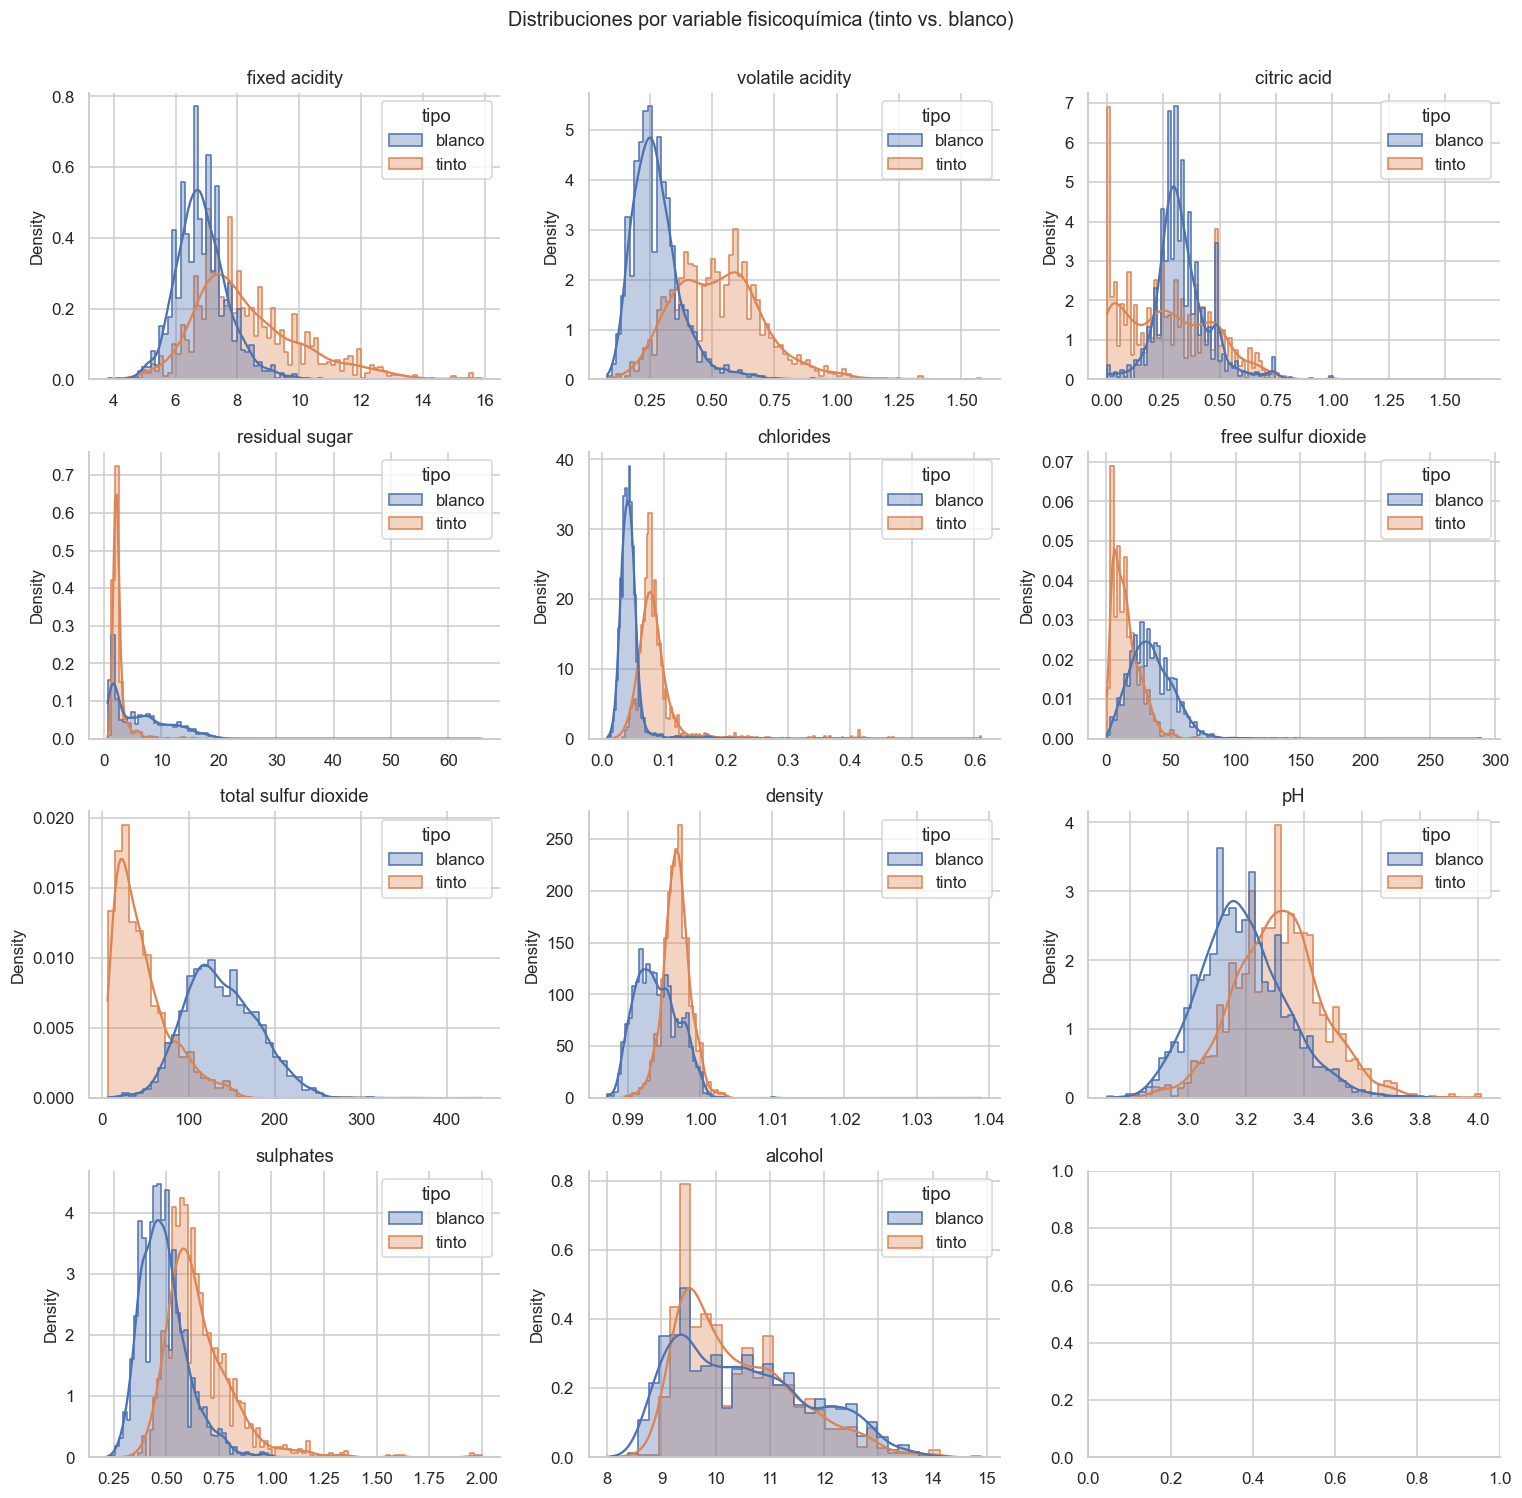

In [88]:
n_vars = len(VARS_FQ)
n_cols = 3
n_filas = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_filas, n_cols, figsize=(14, 3.4 * n_filas))
axes = axes.flat

for ax, var in zip(axes, VARS_FQ):
    sns.histplot(
        data=vinos, x=var, hue="tipo",
        kde=True, stat="density", common_norm=False,
        element="step", alpha=0.35, ax=ax,
    )
    ax.set_title(var)
    ax.set_xlabel("")

for ax in list(axes)[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Distribuciones por variable fisicoquímica (tinto vs. blanco)",
             fontsize=13, y=1.00)
fig.tight_layout()
guardar_figura("fig_u2_01_distribuciones")
plt.show()

#### 2.1.3 Boxplots por tipo de vino

Los diagramas de caja resumen las cinco medidas de posición (mín., Q1, mediana, Q3, máx.) y exponen la presencia de valores extremos. Aquí la inspección es **preliminar**; el tratamiento formal de atípicos se aborda en la Unidad 3.

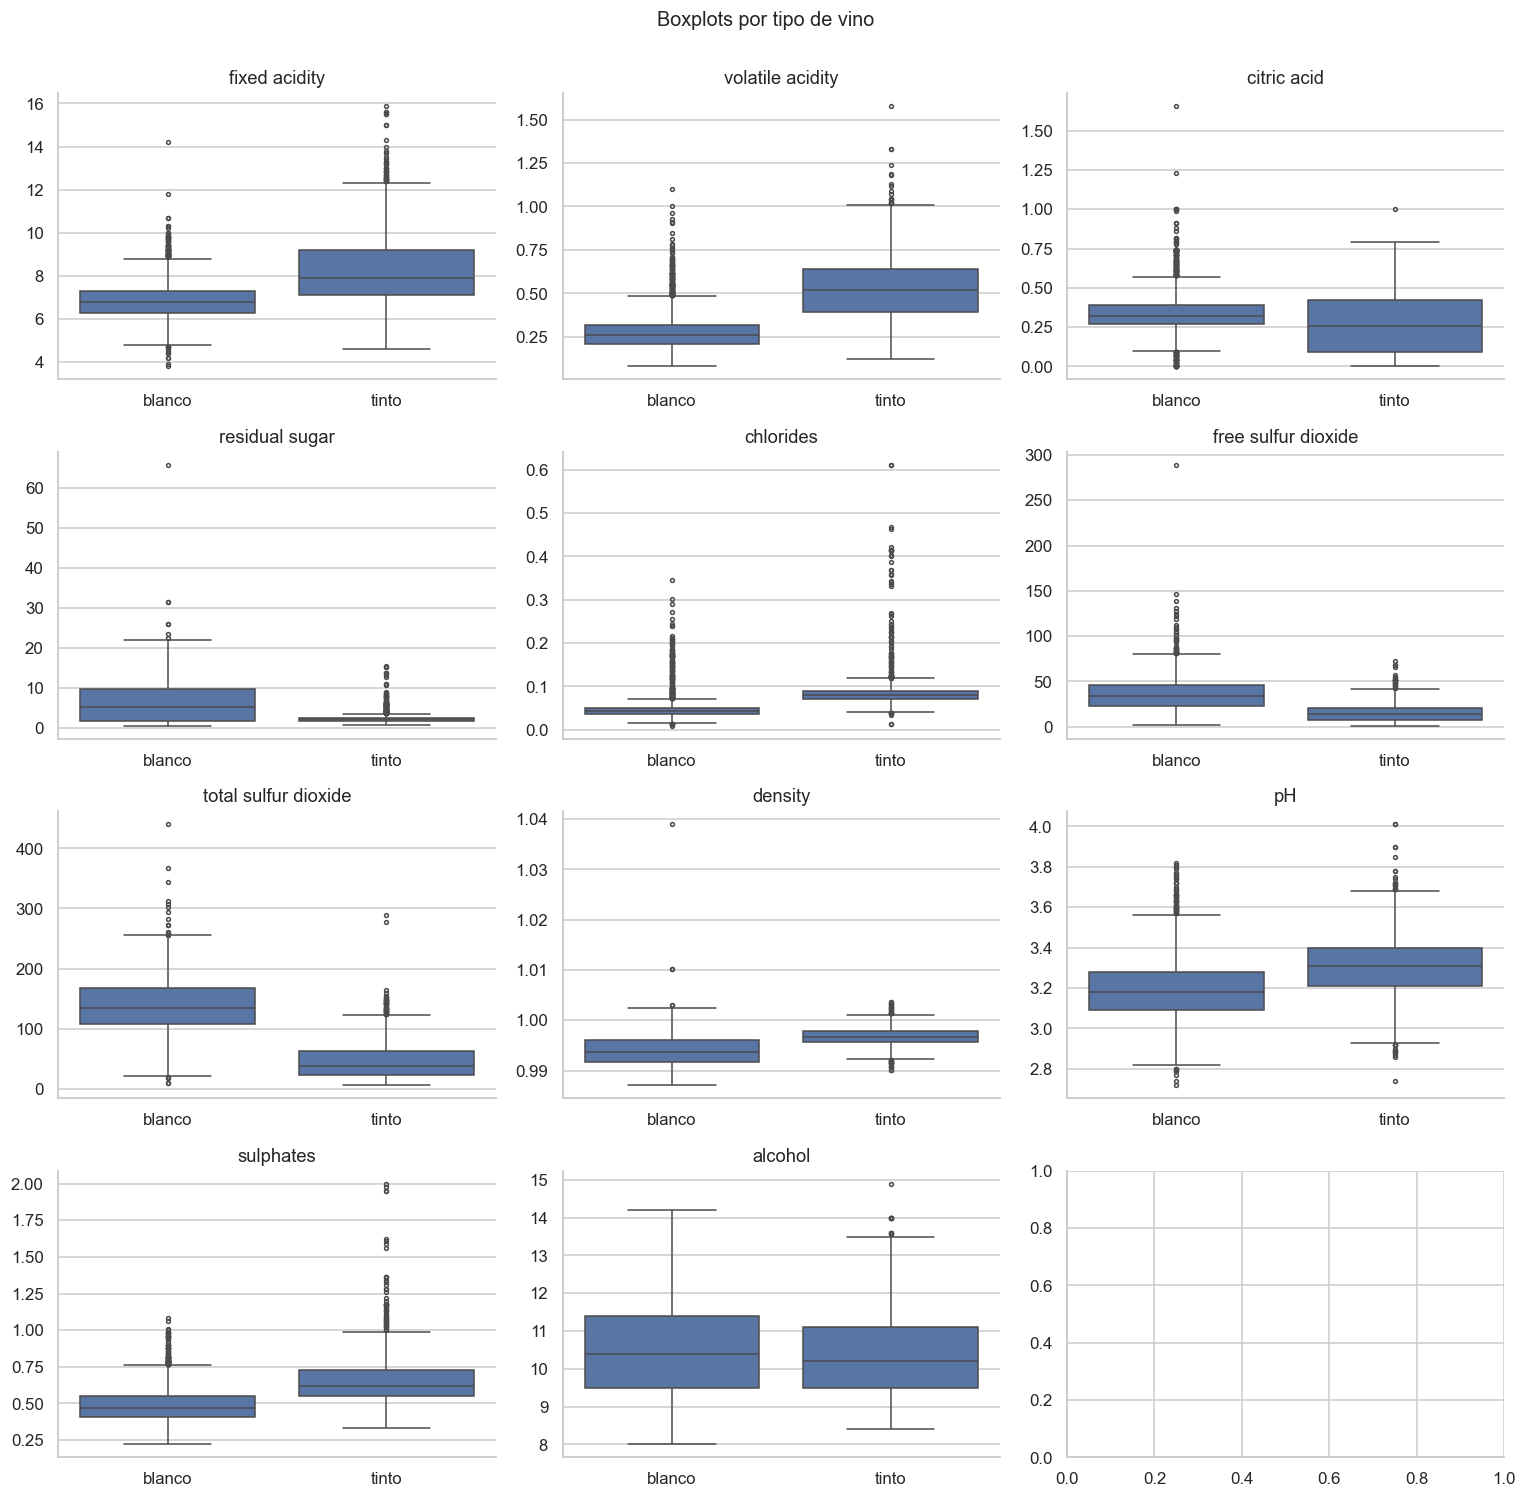

In [89]:
fig, axes = plt.subplots(n_filas, n_cols, figsize=(14, 3.4 * n_filas))
axes = axes.flat

for ax, var in zip(axes, VARS_FQ):
    sns.boxplot(data=vinos, x="tipo", y=var, ax=ax,
                showfliers=True, fliersize=2.5)
    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in list(axes)[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Boxplots por tipo de vino", fontsize=13, y=1.00)
fig.tight_layout()
guardar_figura("fig_u2_02_boxplots_tipo")
plt.show()

#### 2.1.4 Variable objetivo: `quality`

`quality` es ordinal y toma valores enteros entre 0 y 10. Antes de cualquier análisis bivariado conviene visualizar su distribución y comprobar el grado de **desbalance** entre clases.

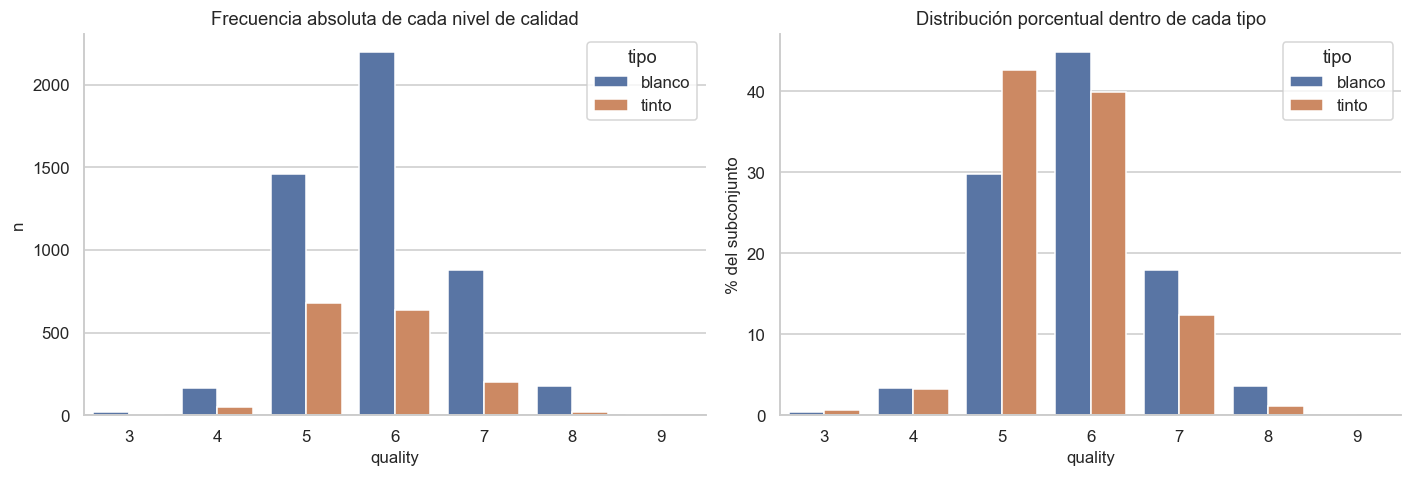

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=vinos, x="quality", hue="tipo", ax=axes[0])
axes[0].set_title("Frecuencia absoluta de cada nivel de calidad")
axes[0].set_ylabel("n")

(
    vinos.groupby("tipo", observed=True)["quality"]
         .value_counts(normalize=True)
         .mul(100).round(2)
         .rename("porcentaje")
         .reset_index()
         .pipe(lambda d: sns.barplot(data=d, x="quality", y="porcentaje",
                                     hue="tipo", ax=axes[1]))
)
axes[1].set_title("Distribución porcentual dentro de cada tipo")
axes[1].set_ylabel("% del subconjunto")

fig.tight_layout()
guardar_figura("fig_u2_03_quality_dist")
plt.show()

### 2.2 Análisis bivariado

El análisis bivariado examina la relación entre **pares de variables**. Empleamos:

- **Coeficiente de Pearson ($r$):** mide relación **lineal** entre dos variables continuas. Sensible a atípicos.
- **Coeficiente de Spearman ($\rho$):** mide relación **monótona** sobre los rangos. Apropiado cuando una de las variables es ordinal (como `quality`) o cuando hay no linealidad/asimetría.
- **Prueba $\chi^2$ de independencia:** evalúa asociación entre dos variables categóricas (aquí, `tipo` vs. `quality` discretizada).
- **Prueba U de Mann–Whitney:** alternativa no paramétrica al test t para comparar distribuciones de una variable continua entre dos grupos (tinto vs. blanco).

#### 2.2.1 Matrices de correlación (Pearson y Spearman)

Calculamos ambas matrices sobre el conjunto unificado para contrastar la estructura **lineal** y la **monótona**. Diferencias notables entre ambas matrices son síntoma de relaciones no lineales.

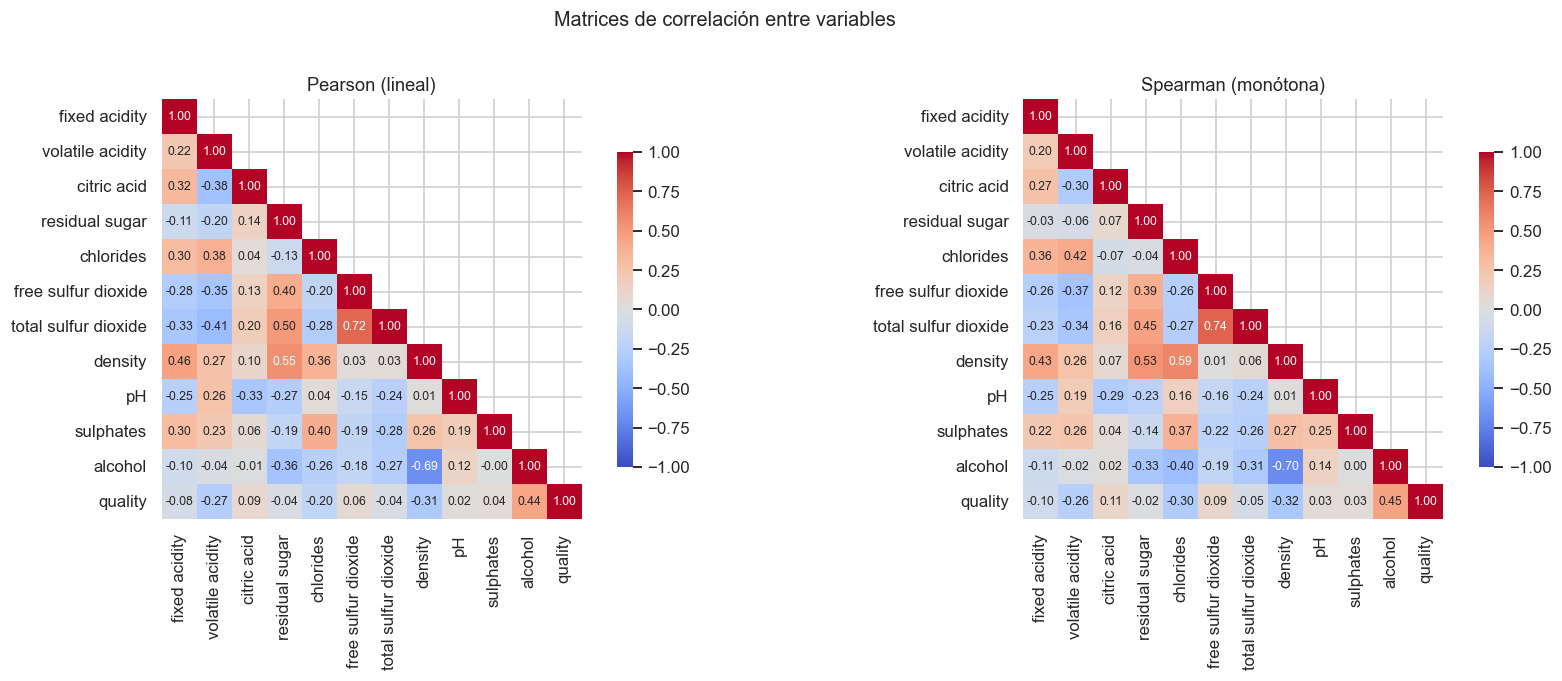

In [91]:
cols_num = VARS_FQ + ["quality"]
corr_pearson = vinos[cols_num].corr(method="pearson")
corr_spearman = vinos[cols_num].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mascara = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)

for ax, matriz, titulo in zip(
    axes,
    [corr_pearson, corr_spearman],
    ["Pearson (lineal)", "Spearman (monótona)"],
):
    sns.heatmap(matriz, mask=mascara, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, vmin=-1, vmax=1,
                square=True, cbar_kws={"shrink": 0.75},
                annot_kws={"size": 8}, ax=ax)
    ax.set_title(titulo)

fig.suptitle("Matrices de correlación entre variables", fontsize=13, y=1.02)
fig.tight_layout()
guardar_figura("fig_u2_04_correlaciones")
plt.show()

#### 2.2.2 Relación de cada variable fisicoquímica con `quality`

Dado que `quality` es ordinal, el coeficiente más adecuado es el de **Spearman**. Ordenamos las variables por la magnitud de su asociación monótona con la calidad para identificar las candidatas más prometedoras como predictoras.

In [92]:
ranking_quality = (
    corr_spearman["quality"]
        .drop("quality")
        .to_frame("ρ_spearman")
        .assign(**{"r_pearson": corr_pearson["quality"].drop("quality")})
        .assign(**{"|ρ|": lambda d: d["ρ_spearman"].abs()})
        .sort_values("|ρ|", ascending=False)
)
ranking_quality

,ρ_spearman,r_pearson,|ρ|
alcohol,0.4469,0.4443,0.4469
density,-0.3228,-0.3059,0.3228
chlorides,-0.2951,-0.2007,0.2951
volatile acidity,-0.2578,-0.2657,0.2578
citric acid,0.1057,0.0855,0.1057
fixed acidity,-0.0982,-0.0767,0.0982
free sulfur dioxide,0.0869,0.0555,0.0869
total sulfur dioxide,-0.0548,-0.0414,0.0548
pH,0.0325,0.0195,0.0325
sulphates,0.0298,0.0385,0.0298


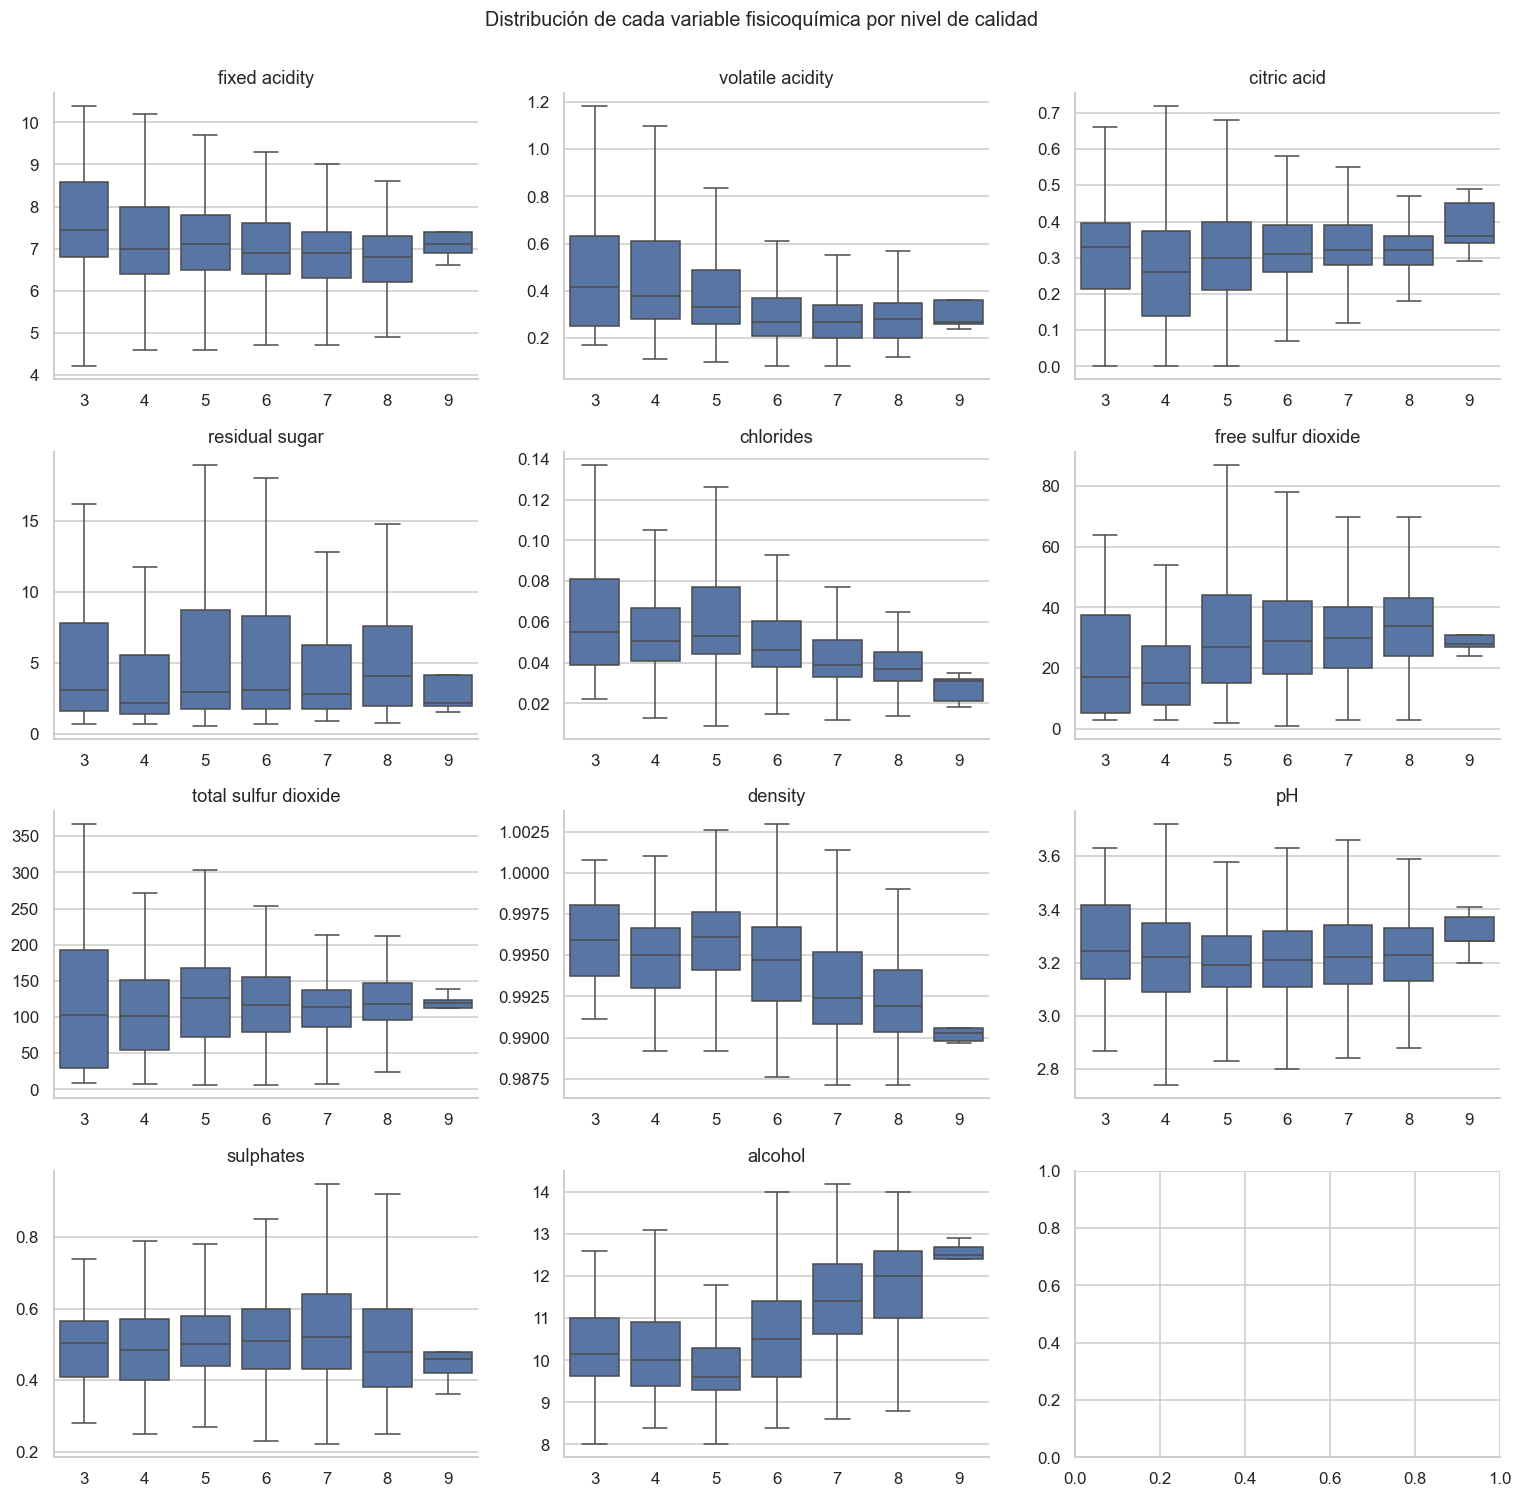

In [93]:
# Visualización: boxplots de cada variable agrupados por nivel de quality.
fig, axes = plt.subplots(n_filas, n_cols, figsize=(14, 3.4 * n_filas))
axes = axes.flat

orden_q = sorted(vinos["quality"].unique())

for ax, var in zip(axes, VARS_FQ):
    sns.boxplot(data=vinos, x="quality", y=var, order=orden_q,
                ax=ax, showfliers=False, color="#4C72B0")
    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in list(axes)[len(VARS_FQ):]:
    ax.set_visible(False)

fig.suptitle("Distribución de cada variable fisicoquímica por nivel de calidad",
             fontsize=13, y=1.00)
fig.tight_layout()
guardar_figura("fig_u2_05_vars_vs_quality")
plt.show()

#### 2.2.3 Comparación tinto vs. blanco

Para cada variable fisicoquímica contrastamos las distribuciones de tinto y blanco mediante la **prueba U de Mann–Whitney**, alternativa no paramétrica al test $t$ que no exige normalidad. La hipótesis nula afirma que ambas distribuciones son iguales.

> **Nota sobre el tamaño muestral.** Con $n_{tinto}=1\,599$ y $n_{blanco}=4\,898$, prácticamente cualquier diferencia produce un *p*-valor extremadamente bajo. Por eso reportamos también la **correlación rank-biserial** $r_{rb} = 1 - 2U/(n_1 n_2)$, una medida no paramétrica del **tamaño del efecto** que toma valores en $[-1, 1]$. Convencionalmente: $|r_{rb}| < 0{,}1$ trivial; $0{,}1$–$0{,}3$ pequeño; $0{,}3$–$0{,}5$ mediano; $> 0{,}5$ grande.

In [94]:
from scipy.stats import mannwhitneyu

filas = []
for var in VARS_FQ:
    a = vinos.loc[vinos["tipo"] == "tinto", var]
    b = vinos.loc[vinos["tipo"] == "blanco", var]
    n1, n2 = len(a), len(b)
    u_stat, p = mannwhitneyu(a, b, alternative="two-sided")
    # Correlación rank-biserial: tamaño del efecto en [-1, 1]
    r_rb = 1 - (2 * u_stat) / (n1 * n2)
    filas.append({
        "variable": var,
        "media_tinto": a.mean(),
        "media_blanco": b.mean(),
        "diferencia": a.mean() - b.mean(),
        "U": u_stat,
        "p_valor": p,
        "r_rb": r_rb,
        "|r_rb|": abs(r_rb),
    })

comparacion_tipos = (pd.DataFrame(filas)
                       .set_index("variable")
                       .sort_values("|r_rb|", ascending=False))
comparacion_tipos

,media_tinto,media_blanco,diferencia,U,p_valor,r_rb,|r_rb|
variable,,,,,,,
total sulfur dioxide,46.4678,138.3607,-91.8929,"366,639.5000",0.0000,0.9064,0.9064
chlorides,0.0875,0.0458,0.0417,"7,407,015.5000",0.0000,-0.8915,0.8915
volatile acidity,0.5278,0.2782,0.2496,"7,059,623.5000",0.0000,-0.8028,0.8028
free sulfur dioxide,15.8749,35.3081,-19.4332,"1,186,396.5000",0.0000,0.6970,0.6970
sulphates,0.6581,0.4898,0.1683,"6,509,961.0000",0.0000,-0.6624,0.6624
fixed acidity,8.3196,6.8548,1.4648,"6,138,507.0000",0.0000,-0.5676,0.5676
density,0.9967,0.9940,0.0027,"6,059,284.5000",0.0000,-0.5473,0.5473
pH,3.3111,3.1883,0.1228,"5,681,839.5000",0.0000,-0.4509,0.4509
residual sugar,2.5388,6.3914,-3.8526,"2,569,687.0000",0.0000,0.3438,0.3438


#### 2.2.4 Asociación entre `tipo` y `quality` ($\chi^2$)

`tipo` es nominal y `quality` es ordinal. La prueba $\chi^2$ de independencia evalúa si la distribución de calidades difiere entre tinto y blanco.

> **Supuesto.** $\chi^2$ requiere que **todas las frecuencias esperadas sean $\geq 5$**. Las clases extremas de `quality` (3 y 9) tienen muy pocas observaciones, por lo que agrupamos `quality` en tres bandas ordenadas que conservan el orden y satisfacen el supuesto: *baja* (3–4), *media* (5–6) y *alta* (7–9). Como medida del tamaño del efecto reportamos la **V de Cramér**.

In [95]:
from scipy.stats import chi2_contingency

# Discretización ordinal de quality (no modifica el DataFrame original).
banda_quality = vinos["quality"].map(
    lambda q: "baja (3-4)" if q <= 4 else ("media (5-6)" if q <= 6 else "alta (7-9)")
)

tabla_contingencia = pd.crosstab(vinos["tipo"], banda_quality)
tabla_contingencia = tabla_contingencia[["baja (3-4)", "media (5-6)", "alta (7-9)"]]

chi2, p_chi2, gl, esperadas = chi2_contingency(tabla_contingencia)

n = tabla_contingencia.values.sum()
k = min(tabla_contingencia.shape) - 1
cramer_v = (chi2 / (n * k)) ** 0.5

print("Tabla de contingencia (frecuencias observadas):")
print(tabla_contingencia)
print(f"\nFrecuencia esperada mínima: {esperadas.min():.1f}  (debe ser >= 5)")
print(f"\nchi^2 = {chi2:.3f}   gl = {gl}   p-valor = {p_chi2:.3e}")
print(f"V de Cramer = {cramer_v:.3f}  "
      f"(0 = sin asociacion; 1 = asociacion perfecta)")

Tabla de contingencia (frecuencias observadas):
quality  baja (3-4)  media (5-6)  alta (7-9)
tipo                                        
blanco          183         3655        1060
tinto            63         1319         217

Frecuencia esperada mínima: 60.5  (debe ser >= 5)

chi^2 = 49.823   gl = 2   p-valor = 1.517e-11
V de Cramer = 0.088  (0 = sin asociacion; 1 = asociacion perfecta)


### 2.3 Análisis multivariado

El análisis multivariado estudia **relaciones simultáneas** entre tres o más variables. Aplicamos **Análisis de Componentes Principales (PCA)**, técnica que proyecta los datos sobre un nuevo sistema de ejes ortogonales —los *componentes principales*— ordenados por la cantidad de varianza que explican.

> **Nota metodológica.** El PCA es **sensible a la escala** de las variables: las que tienen mayor varianza absoluta dominarían los componentes. Por ello se aplica `StandardScaler` (media 0, desviación 1) **únicamente como paso técnico interno del PCA**. El escalamiento como etapa formal del preprocesamiento se trata en la Unidad 4.

In [96]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = vinos[VARS_FQ].values
y_quality = vinos["quality"].values
y_tipo = vinos["tipo"].values

X_std = StandardScaler().fit_transform(X)

pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(X_std)

varianza = pca.explained_variance_ratio_
varianza_acum = varianza.cumsum()

resumen_pca = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(varianza))],
    "varianza_explicada": varianza,
    "varianza_acumulada": varianza_acum,
})
resumen_pca

,componente,varianza_explicada,varianza_acumulada
0,PC1,0.2754,0.2754
1,PC2,0.2267,0.5022
2,PC3,0.1415,0.6436
3,PC4,0.0882,0.7319
4,PC5,0.0654,0.7973
5,PC6,0.0552,0.8525
6,PC7,0.0476,0.9001
7,PC8,0.0456,0.9457
8,PC9,0.0306,0.9763
9,PC10,0.0207,0.9970


#### 2.3.1 Varianza explicada (scree plot)

El *scree plot* permite decidir cuántos componentes retener. Un criterio frecuente es conservar los componentes que en conjunto expliquen al menos el **70–80 %** de la varianza.

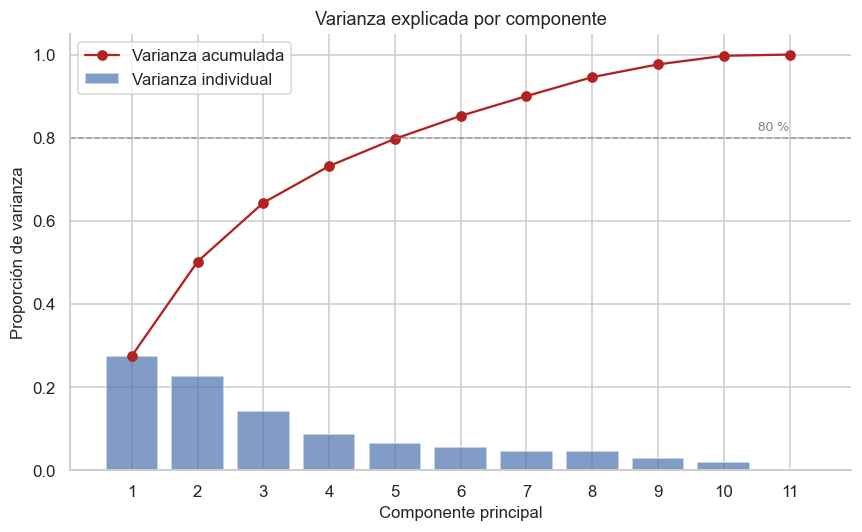

In [97]:
fig, ax = plt.subplots(figsize=(8, 5))
componentes = np.arange(1, len(varianza) + 1)

ax.bar(componentes, varianza, alpha=0.7, label="Varianza individual")
ax.plot(componentes, varianza_acum, marker="o", color="firebrick",
        label="Varianza acumulada")

ax.axhline(0.80, ls="--", color="gray", lw=1, alpha=0.7)
ax.text(len(varianza), 0.81, "80 %", color="gray",
        ha="right", va="bottom", fontsize=9)

ax.set_xlabel("Componente principal")
ax.set_ylabel("Proporción de varianza")
ax.set_title("Varianza explicada por componente")
ax.set_xticks(componentes)
ax.legend()

fig.tight_layout()
guardar_figura("fig_u2_06_pca_varianza")
plt.show()

#### 2.3.2 Proyección sobre el plano PC1–PC2

Visualizamos las observaciones en el plano definido por los dos primeros componentes, coloreando primero por `tipo` (¿se separan tinto y blanco en el espacio reducido?) y luego por `quality` (¿hay un gradiente asociado a la calidad?).

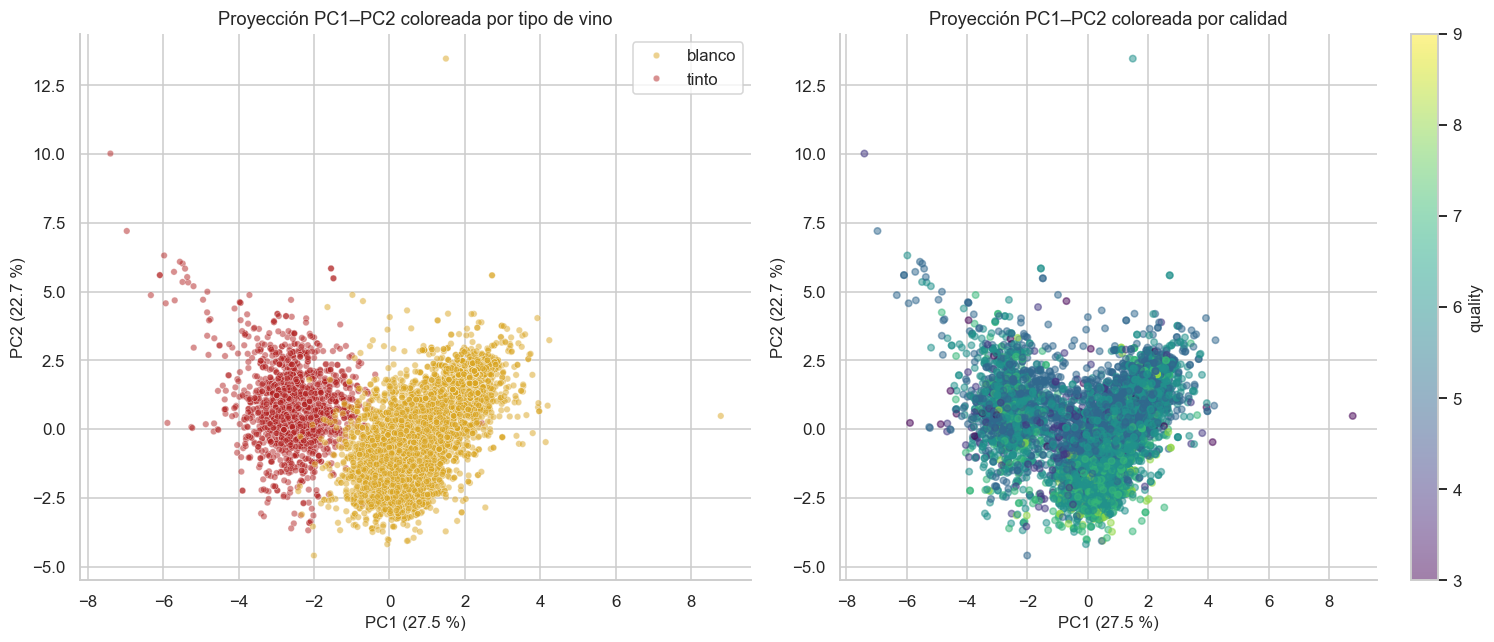

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Coloreado por tipo
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=y_tipo, alpha=0.5, s=18,
                palette={"tinto": "#B22222", "blanco": "#DAA520"},
                ax=axes[0])
axes[0].set_title("Proyección PC1–PC2 coloreada por tipo de vino")
axes[0].set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
axes[0].set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")

# Coloreado por quality
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=y_quality, cmap="viridis", alpha=0.5, s=18)
axes[1].set_title("Proyección PC1–PC2 coloreada por calidad")
axes[1].set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
axes[1].set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")
plt.colorbar(sc, ax=axes[1], label="quality")

fig.tight_layout()
guardar_figura("fig_u2_07_pca_scatter")
plt.show()

#### 2.3.3 Cargas factoriales y biplot

Las **cargas** (componentes de los autovectores) indican el peso de cada variable original sobre cada componente principal. El *biplot* superpone la nube de observaciones con los vectores de carga, facilitando la interpretación de la dirección de cada componente.

In [99]:
cargas = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=VARS_FQ,
)
cargas[["PC1", "PC2", "PC3"]].round(3)

,PC1,PC2,PC3
fixed acidity,-0.2390,0.3360,0.4340
volatile acidity,-0.3810,0.1180,-0.3070
citric acid,0.1520,0.1830,0.5910
residual sugar,0.3460,0.3300,-0.1650
chlorides,-0.2900,0.3150,-0.0170
free sulfur dioxide,0.4310,0.0720,-0.1340
total sulfur dioxide,0.4870,0.0870,-0.1070
density,-0.0450,0.5840,-0.1760
pH,-0.2190,-0.1560,-0.4550
sulphates,-0.2940,0.1920,0.0700


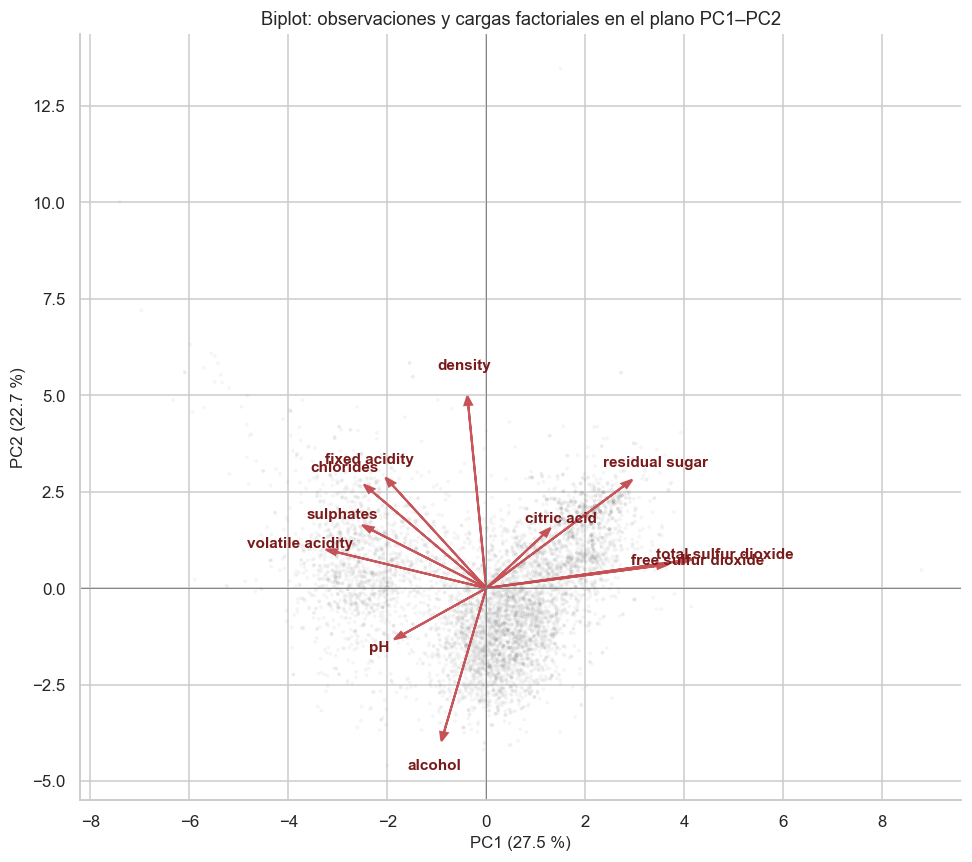

In [100]:
# Biplot: scatter de observaciones (fondo tenue) + flechas de cargas en PC1-PC2.
fig, ax = plt.subplots(figsize=(9, 8))

# Fondo muy discreto para no competir con las flechas
ax.scatter(X_pca[:, 0], X_pca[:, 1],
           c="#888888", alpha=0.08, s=6, edgecolors="none")

escala = 1.15 * max(abs(X_pca[:, 0]).max(), abs(X_pca[:, 1]).max())
escala_flecha = escala * 0.55

for var, (pc1, pc2) in zip(VARS_FQ, pca.components_[:2].T):
    ax.arrow(0, 0, pc1 * escala_flecha, pc2 * escala_flecha,
             color="#C44E52", alpha=0.95, head_width=0.15, lw=1.4,
             length_includes_head=True)
    ax.text(pc1 * escala_flecha * 1.16, pc2 * escala_flecha * 1.16,
            var, color="#7A1A1A", fontsize=10, ha="center", va="center",
            fontweight="bold")

ax.axhline(0, color="gray", lw=0.6)
ax.axvline(0, color="gray", lw=0.6)
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")
ax.set_title("Biplot: observaciones y cargas factoriales en el plano PC1–PC2")

fig.tight_layout()
guardar_figura("fig_u2_08_pca_biplot")
plt.show()

### 2.4 Síntesis de hallazgos del EDA

A partir del análisis univariado, bivariado y multivariado se desprenden las observaciones que enmarcan las decisiones de las unidades posteriores.

> **Nota sobre la base.** El análisis se realizó conservando los **1 177 registros duplicados exactos** (18,1 % del conjunto unificado) detectados en la Unidad 1. Su tratamiento formal se aborda en la Unidad 4; conviene tener presente que pueden inflar marginalmente las densidades locales y, por tanto, las correlaciones reportadas.

**Univariado.**
- Varias variables presentan distribuciones marcadamente **asimétricas a la derecha** (asimetría > 1), notablemente `residual sugar`, `chlorides` y, en el vino tinto, `sulphates`. Este sesgo motiva el uso de transformaciones potencia (Yeo–Johnson) en la Unidad 4.
- `density` y `pH` se aproximan a una distribución casi simétrica, mientras que `alcohol` muestra una distribución sesgada con cola hacia valores altos.
- `quality` está fuertemente concentrada en los niveles 5 y 6; las clases extremas (3, 4, 8, 9) son muy escasas, lo que constituye un caso típico de **desbalance ordinal** que limitará cualquier modelado supervisado posterior.

**Bivariado.**
- La variable con mayor asociación monótona positiva con `quality` es **`alcohol`** ($\rho \approx 0{,}45$). En sentido negativo destacan **`density`** ($\rho \approx -0{,}32$), **`chlorides`** ($\rho \approx -0{,}30$) y **`volatile acidity`** ($\rho \approx -0{,}26$). Este patrón es consistente con el reportado en la literatura del *dataset* (Cortez et al., 2009).
- La diferencia entre Pearson y Spearman es marginal en general, pero notoria para `chlorides` ($r \approx -0{,}20$ vs. $\rho \approx -0{,}30$), lo que sugiere una **relación monótona no estrictamente lineal**.
- La prueba U de Mann–Whitney rechaza la igualdad distribucional entre tinto y blanco en prácticamente todas las variables; dado el gran tamaño muestral, las pruebas de significancia son poco discriminantes. El tamaño del efecto (rank-biserial $|r_{rb}|$) revela diferencias **muy grandes** ($|r_{rb}| > 0{,}7$) en `total sulfur dioxide`, `chlorides`, `volatile acidity` y `free sulfur dioxide`, lo que confirma que se trata de **diferencias químicas estructurales** entre ambos tipos de vino, no artefactos del tamaño muestral.
- La prueba $\chi^2$ sobre `quality` agrupada en tres bandas confirma una asociación estadísticamente significativa entre `tipo` y `quality`, con un tamaño del efecto (V de Cramér) **pequeño**: el tipo de vino influye, pero no determina, la calidad sensorial percibida.

**Multivariado.**
- El PCA distribuye la varianza de forma **relativamente uniforme** entre los componentes: PC1 explica el 27,5 %, PC2 el 22,7 % y se requieren **cinco componentes** para alcanzar el 80 %. La información del conjunto está dispersa en múltiples direcciones del espacio de 11 variables, no concentrada en una o dos.
- **PC1 (27,5 %)** es esencialmente un eje **químico de tipo de vino**: en el extremo positivo se concentran observaciones con alto $\mathrm{SO}_2$ libre y total y mayor azúcar residual (perfil blanco); en el negativo, mayor acidez volátil, sulfatos y cloruros (perfil tinto). Esto explica la separación visualmente nítida en el plano PC1–PC2.
- **PC2 (22,7 %)** captura el clásico contraste **densidad versus alcohol**: la densidad del vino disminuye al aumentar el alcohol (menos denso que el agua) y aumenta con el azúcar residual. Es un eje de "estructura corporal" del vino.
- **PC3 (14,2 %)** es un eje de **acidez total**: ácido cítrico y acidez fija con cargas positivas frente a pH con carga negativa, una relación químicamente consistente (a mayor concentración de ácidos, menor pH).
- Lo más relevante para la pregunta de investigación es que **el gradiente de `quality` sobre el plano PC1–PC2 es difuso**: no hay una dirección lineal clara que explique la calidad. Esto sugiere que predecirla exigirá modelos con capacidad para capturar **interacciones y relaciones no lineales** (árboles, ensambles, redes), más allá de combinaciones lineales de los atributos originales.

> **Próxima unidad (U3 — Detección de atípicos).** Se aplicarán métodos gráficos (boxplot), estadísticos (regla del rango intercuartílico y *Z-score*) y de aprendizaje automático (*Isolation Forest* y *Local Outlier Factor*) para identificar y documentar valores anómalos, contrastando los conjuntos de observaciones marcadas por cada técnica.

---

## 3. Detección y tratamiento de datos atípicos (Unidad 3)

Los **datos atípicos** (*outliers*) son observaciones que se apartan notablemente del comportamiento general del resto de los datos. Su presencia puede sesgar coeficientes de correlación, distorsionar estadísticos sensibles a la escala (media, varianza, PCA) y comprometer las conclusiones de un análisis (Barnett & Lewis, 1994).

En esta unidad identificamos y documentamos los valores potencialmente atípicos del conjunto *Wine Quality* aplicando **tres familias de técnicas** correspondientes a las orientaciones de la rúbrica y de la sesión teórica:

| Familia | Técnicas aplicadas |
|---|---|
| **Métodos gráficos** | Diagramas de caja (`fig_u2_02_boxplots_tipo`, Unidad 2). |
| **Métodos estadísticos** | Regla del **rango intercuartílico (IQR)**; **puntaje Z** ($Z$-score). |
| **Aprendizaje automático** | **Isolation Forest**; **Local Outlier Factor (LOF)**. |

> **Sobre el alcance.** La rúbrica pide *identificar y documentar* los valores anómalos. En esta unidad **no se eliminan ni se imputan** observaciones: caracterizamos qué tantas, dónde y bajo qué criterio se detectan. La decisión de eliminación o imputación se ejecuta en la Unidad 4.

> **Nota metodológica.** La detección se realiza sobre el conjunto unificado (tinto + blanco) para mantener simplicidad y coherencia con las sesiones teóricas. Una opción más fina sería realizar la detección **por tipo**, dado que ambos subconjuntos difieren estructuralmente (Unidad 2); lo registramos como línea futura.

### 3.1 Detección univariada con métodos gráficos y estadísticos

Los métodos univariados examinan **una variable a la vez** y marcan como atípica toda observación cuyo valor caiga fuera de un rango definido a partir de estadísticos descriptivos.

#### 3.1.1 Inspección visual: diagramas de caja

Los boxplots de la Unidad 2 (`fig_u2_02_boxplots_tipo`) ya ofrecen una primera lectura de los atípicos univariados: los puntos dibujados más allá de los "bigotes" corresponden a observaciones cuyo valor excede $Q_3 + 1.5\,\mathrm{IQR}$ o cae por debajo de $Q_1 - 1.5\,\mathrm{IQR}$. Esta visualización guía la elección formal de los criterios cuantitativos que aplicamos a continuación.

#### 3.1.2 Regla del rango intercuartílico (IQR)

Una observación $x$ se considera atípica si

$$
x < Q_1 - 1.5\,\mathrm{IQR} \quad \text{o} \quad x > Q_3 + 1.5\,\mathrm{IQR},
$$

donde $\mathrm{IQR} = Q_3 - Q_1$. Es un criterio **robusto**: $Q_1$, $Q_3$ y la mediana son insensibles a los valores extremos, por lo que el método se desempeña bien en distribuciones asimétricas.

In [ ]:
def detectar_iqr(serie, k=1.5):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - k * iqr
    lim_sup = q3 + k * iqr
    mascara = (serie < lim_inf) | (serie > lim_sup)
    return mascara, lim_inf, lim_sup


resumen_iqr = []
mascaras_iqr = pd.DataFrame(index=vinos.index)

for var in VARS_FQ:
    mascara, li, ls = detectar_iqr(vinos[var])
    mascaras_iqr[var] = mascara
    resumen_iqr.append({
        "variable": var,
        "Q1": vinos[var].quantile(0.25),
        "Q3": vinos[var].quantile(0.75),
        "lim_inf": li,
        "lim_sup": ls,
        "n_atipicos": int(mascara.sum()),
        "% atipicos": 100 * mascara.sum() / len(vinos),
    })

resumen_iqr = (pd.DataFrame(resumen_iqr)
                 .set_index("variable")
                 .sort_values("% atipicos", ascending=False))
resumen_iqr

In [ ]:
# Observaciones marcadas como atípicas por IQR en al menos una variable
atipicos_iqr_global = mascaras_iqr.any(axis=1)
print(f"Observaciones atípicas según IQR (en al menos 1 variable): "
      f"{atipicos_iqr_global.sum():,} de {len(vinos):,} "
      f"({100 * atipicos_iqr_global.mean():.2f} %)")

#### 3.1.3 Puntaje Z (*Z-score*)

El puntaje Z estandariza cada valor respecto a la media y la desviación estándar:

$$
z_i = \frac{x_i - \bar{x}}{s_x}.
$$

Una observación se marca como atípica si $|z_i| > 3$, es decir, si está a más de 3 desviaciones estándar de la media. Es un criterio que **asume aproximada normalidad** y es sensible a la propia presencia de atípicos (la desviación estándar se infla). Por eso suele complementar —no sustituir— al IQR.

In [ ]:
from scipy.stats import zscore

UMBRAL_Z = 3.0

z_scores = vinos[VARS_FQ].apply(zscore)
mascaras_z = z_scores.abs() > UMBRAL_Z

resumen_z = pd.DataFrame({
    "n_atipicos": mascaras_z.sum(),
    "% atipicos": 100 * mascaras_z.sum() / len(vinos),
}).sort_values("% atipicos", ascending=False)
resumen_z

In [ ]:
atipicos_z_global = mascaras_z.any(axis=1)
print(f"Observaciones atípicas según Z-score (|z| > {UMBRAL_Z}, en al menos 1 variable): "
      f"{atipicos_z_global.sum():,} de {len(vinos):,} "
      f"({100 * atipicos_z_global.mean():.2f} %)")

#### 3.1.4 Concordancia entre IQR y *Z-score*

Ambos criterios detectan información parcialmente distinta: el IQR es robusto y suele ser **más sensible** en presencia de asimetría, mientras que el *Z-score* identifica colas pesadas relativas a una referencia gaussiana. Comparamos el conteo por variable y la coincidencia a nivel de observación.

In [ ]:
comparacion_uni = pd.DataFrame({
    "IQR": mascaras_iqr.sum(),
    "Z-score": mascaras_z.sum(),
    "Δ (IQR - Z)": mascaras_iqr.sum() - mascaras_z.sum(),
}).sort_values("IQR", ascending=False)
comparacion_uni

In [ ]:
# Coincidencia a nivel de observación
solo_iqr = atipicos_iqr_global & ~atipicos_z_global
solo_z   = ~atipicos_iqr_global & atipicos_z_global
ambos    = atipicos_iqr_global & atipicos_z_global
ninguno  = ~atipicos_iqr_global & ~atipicos_z_global

print("Coincidencia IQR vs. Z-score a nivel de observación:")
print(f"  Solo IQR    : {solo_iqr.sum():>5} ({100*solo_iqr.mean():.2f} %)")
print(f"  Solo Z-score: {solo_z.sum():>5} ({100*solo_z.mean():.2f} %)")
print(f"  Ambos       : {ambos.sum():>5} ({100*ambos.mean():.2f} %)")
print(f"  Ninguno     : {ninguno.sum():>5} ({100*ninguno.mean():.2f} %)")

### 3.2 Detección multivariada con aprendizaje automático

Los métodos univariados no capturan **combinaciones inusuales** de variables que individualmente son normales. Para ello recurrimos a dos algoritmos no supervisados ampliamente utilizados en la literatura de *outlier detection* y cubiertos en la sesión teórica de la profesora:

- **Isolation Forest** (Liu, Ting & Zhou, 2008): construye árboles aleatorios que aíslan observaciones; los puntos atípicos requieren menos divisiones para ser separados del resto. Bueno con datos de alta dimensionalidad y eficiente en cómputo.
- **Local Outlier Factor (LOF)** (Breunig et al., 2000): mide la *densidad local* alrededor de cada observación; un punto con densidad mucho menor que la de sus vecinos se considera atípico. Detecta atípicos *contextuales* a la estructura local.

Ambos se aplican sobre los datos **estandarizados** (`X_std`, ya calculado en la Unidad 2 para el PCA), evitando que las variables con mayor varianza absoluta dominen la noción de distancia. Fijamos `contamination=0.05` (5 %) en ambos métodos para favorecer la comparabilidad directa.

#### 3.2.1 Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

CONTAMINACION = 0.05

iso = IsolationForest(
    contamination=CONTAMINACION,
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
)
pred_if = iso.fit_predict(X_std)        # -1 = atípico; +1 = inlier
score_if = -iso.score_samples(X_std)    # mayor = más atípico

mascara_if = pred_if == -1
print(f"Isolation Forest marca {mascara_if.sum():,} observaciones como atípicas "
      f"({100 * mascara_if.mean():.2f} % del total).")

In [ ]:
# Visualización en el plano PC1–PC2 ya calculado en U2
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(X_pca[~mascara_if, 0], X_pca[~mascara_if, 1],
           c="#BBBBBB", alpha=0.35, s=10, label="Normal", edgecolors="none")
ax.scatter(X_pca[mascara_if, 0], X_pca[mascara_if, 1],
           c="#C44E52", alpha=0.75, s=18, label="Atípico (IF)", edgecolors="none")
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")
ax.set_title("Atípicos detectados por Isolation Forest (proyección PC1–PC2)")
ax.legend(loc="upper right")
fig.tight_layout()
guardar_figura("fig_u3_01_isolation_forest")
plt.show()

#### 3.2.2 Local Outlier Factor (LOF)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

N_VECINOS = 20  # tamaño de vecindario habitual para LOF

lof = LocalOutlierFactor(
    n_neighbors=N_VECINOS,
    contamination=CONTAMINACION,
    n_jobs=-1,
)
pred_lof = lof.fit_predict(X_std)
score_lof = -lof.negative_outlier_factor_

mascara_lof = pred_lof == -1
print(f"LOF marca {mascara_lof.sum():,} observaciones como atípicas "
      f"({100 * mascara_lof.mean():.2f} % del total).")

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(X_pca[~mascara_lof, 0], X_pca[~mascara_lof, 1],
           c="#BBBBBB", alpha=0.35, s=10, label="Normal", edgecolors="none")
ax.scatter(X_pca[mascara_lof, 0], X_pca[mascara_lof, 1],
           c="#4C72B0", alpha=0.75, s=18, label="Atípico (LOF)", edgecolors="none")
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")
ax.set_title("Atípicos detectados por Local Outlier Factor (proyección PC1–PC2)")
ax.legend(loc="upper right")
fig.tight_layout()
guardar_figura("fig_u3_02_lof")
plt.show()

#### 3.2.3 Concordancia entre Isolation Forest y LOF

Ambos métodos están calibrados al mismo nivel de contaminación, por lo que el número total de atípicos es comparable. Lo relevante es preguntar **cuántos de los puntos marcados son los mismos** en cada método: una alta coincidencia sugiere atípicos *robustos*; una baja coincidencia indica que cada algoritmo está capturando una geometría diferente de la anomalía.

In [ ]:
matriz_acuerdo = pd.crosstab(
    pd.Series(mascara_if, name="Isolation Forest"),
    pd.Series(mascara_lof, name="LOF"),
    margins=True, margins_name="Total"
)
matriz_acuerdo.index = ["Normal", "Atípico", "Total"]
matriz_acuerdo.columns = ["Normal", "Atípico", "Total"]
matriz_acuerdo

In [ ]:
# Visualización conjunta: distinguir intersección y disjunciones
solo_if  = mascara_if & ~mascara_lof
solo_lof = ~mascara_if & mascara_lof
ambos_ml = mascara_if & mascara_lof
normales = ~(mascara_if | mascara_lof)

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(X_pca[normales, 0], X_pca[normales, 1],
           c="#CCCCCC", alpha=0.25, s=8, edgecolors="none", label=f"Normal ({normales.sum():,})")
ax.scatter(X_pca[solo_if, 0], X_pca[solo_if, 1],
           c="#C44E52", alpha=0.8, s=18, edgecolors="none", label=f"Solo IF ({solo_if.sum():,})")
ax.scatter(X_pca[solo_lof, 0], X_pca[solo_lof, 1],
           c="#4C72B0", alpha=0.8, s=18, edgecolors="none", label=f"Solo LOF ({solo_lof.sum():,})")
ax.scatter(X_pca[ambos_ml, 0], X_pca[ambos_ml, 1],
           c="#8E44AD", alpha=0.9, s=22, edgecolors="none", label=f"Ambos ({ambos_ml.sum():,})")

ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")
ax.set_title("Concordancia entre Isolation Forest y LOF (proyección PC1–PC2)")
ax.legend(loc="upper right", framealpha=0.92)
fig.tight_layout()
guardar_figura("fig_u3_03_concordancia_ml")
plt.show()

### 3.3 Síntesis y plan de tratamiento

Consolidamos los cuatro indicadores binarios en un único cuadro por observación para cuantificar las coincidencias entre familias y orientar el tratamiento que se ejecutará en la Unidad 4.

In [ ]:
banderas_atipico = pd.DataFrame({
    "IQR": atipicos_iqr_global.values,
    "Z-score": atipicos_z_global.values,
    "Isolation Forest": mascara_if,
    "LOF": mascara_lof,
}, index=vinos.index)

# Cuántos métodos marcan cada observación
banderas_atipico["n_metodos"] = banderas_atipico.sum(axis=1)

print("Distribución del número de métodos que marcan cada observación:")
print(banderas_atipico["n_metodos"].value_counts().sort_index().to_string())

print(f"\nResumen global:")
print(f"  Observaciones marcadas por al menos 1 método: "
      f"{(banderas_atipico['n_metodos'] >= 1).sum():,} "
      f"({100*(banderas_atipico['n_metodos'] >= 1).mean():.2f} %)")
print(f"  Observaciones marcadas por >= 3 métodos     : "
      f"{(banderas_atipico['n_metodos'] >= 3).sum():,} "
      f"({100*(banderas_atipico['n_metodos'] >= 3).mean():.2f} %)")
print(f"  Observaciones marcadas por los 4 métodos    : "
      f"{(banderas_atipico['n_metodos'] == 4).sum():,} "
      f"({100*(banderas_atipico['n_metodos'] == 4).mean():.2f} %)")

**Hallazgos del análisis de atípicos.**

- Los métodos **univariados** (IQR y Z-score) marcan una fracción importante de observaciones como atípicas, concentradas en las variables con mayor asimetría (`residual sugar`, `chlorides`, `sulphates`). Esto es esperable: la regla del IQR aplicada a una distribución sesgada produce muchos "falsos positivos" desde el punto de vista del proceso generador, ya que la cola larga es legítima del fenómeno y no un error.
- El criterio del **Z-score** detecta sistemáticamente menos atípicos que el IQR. La razón es que la propia presencia de valores extremos infla la desviación estándar muestral, ampliando el umbral $\pm 3s$ y reduciendo así la sensibilidad del criterio. El IQR, basado en cuantiles, es más robusto en este escenario.
- Los métodos **multivariados** (Isolation Forest y LOF), calibrados a un 5 % de contaminación, marcan el mismo número total de observaciones por construcción, pero su **coincidencia exacta es modesta**: cada algoritmo captura una noción geométricamente distinta de anomalía (aislamiento global por IF, densidad local por LOF). Los puntos marcados por **ambos** constituyen los atípicos multivariados más robustos.
- Las **observaciones marcadas por tres o cuatro métodos simultáneamente** son los candidatos más sólidos para etiquetar como anomalía y constituyen una fracción pequeña del conjunto.

**Plan de tratamiento para la Unidad 4.**

Dado que las distribuciones son intrínsecamente asimétricas y muchas observaciones "atípicas" son extremas pero legítimas, **no se eliminarán** los atípicos univariados de forma indiscriminada. La estrategia será:

1. **Transformar** las variables con asimetría alta (`residual sugar`, `chlorides`, `sulphates`) mediante una transformación Yeo–Johnson para reducir el sesgo y comprimir las colas; esto reduce la sensibilidad posterior a valores extremos.
2. **Conservar** los outliers univariados restantes, dado que reflejan variabilidad química real del vino.
3. **Inspeccionar manualmente** las observaciones marcadas por **los cuatro métodos simultáneamente** como candidatas a posible error de registro; decidir caso por caso si excluirlas.
4. **Documentar** la decisión final tomada y reportar el tamaño del conjunto resultante.

> **Próxima unidad (U4 — Imputación, escalamiento y transformación).** Se aborda el manejo de duplicados, la transformación de variables sesgadas, el escalamiento formal y la consolidación del conjunto procesado que servirá de base para análisis o modelado posterior.

---